In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
counts_nmdb=pd.read_csv("Jung_Mosc_1964_2026.txt",skiprows=25,delimiter=";")
counts_nmdb["DATETIME"]=pd.to_datetime(counts_nmdb["DATETIME"])
counts_nmdb.set_index("DATETIME",inplace=True)
counts_nmdb=counts_nmdb.replace("   null",np.nan)
counts_nmdb=counts_nmdb.astype(float)
counts_nmdb=counts_nmdb[counts_nmdb.index<="2025-12-31"]
counts_nmdb

,JUNG,MOSC
DATETIME,,
1964-01-01,163.824,232.529
1964-01-02,162.334,230.618
1964-01-03,160.586,230.268
1964-01-04,NaN,229.929
1964-01-05,163.766,231.529
...,...,...
2025-12-27,143.895,NaN
2025-12-28,145.154,NaN
2025-12-29,145.643,NaN


In [3]:
counts_omni=pd.read_csv("OMNI_1964_2026.txt",delimiter="\s+",
                        names=["YEAR","DOY","Hour","Scalar B, nT","SW Plasma Temperature, K",
                               "SW Proton Density, N/cm^3","SW Plasma Speed, km/s","R (Sunspot No.)",
                               "Dst-index, nT"])
counts_omni=counts_omni.replace(9999999.,np.nan)
counts_omni=counts_omni.replace(999.9,np.nan)
counts_omni=counts_omni.replace(9999.0,np.nan)
counts_omni["DATETIME"]=pd.date_range("1964-01-01",periods=len(counts_omni),freq="D")
counts_omni.set_index("DATETIME",inplace=True)
counts_omni=counts_omni.drop(columns=["YEAR","DOY","Hour"])
counts_omni=counts_omni.astype(float)
counts_omni=counts_omni[counts_omni.index<="2025-12-31"]
counts_omni

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_2611/3652441365.py:1: SyntaxWarning: invalid escape sequence '\s'
  counts_omni=pd.read_csv("OMNI_1964_2026.txt",delimiter="\s+",


,"Scalar B, nT","SW Plasma Temperature, K","SW Proton Density, N/cm^3","SW Plasma Speed, km/s",R (Sunspot No.),"Dst-index, nT"
DATETIME,,,,,,
1964-01-01,7.8,NaN,30.7,328.0,0.0,11.0
1964-01-02,8.3,NaN,10.9,505.0,21.0,-41.0
1964-01-03,4.5,NaN,4.3,499.0,12.0,-32.0
1964-01-04,4.6,NaN,4.2,492.0,11.0,-25.0
1964-01-05,3.5,NaN,4.6,375.0,19.0,-19.0
...,...,...,...,...,...,...
2025-12-27,5.0,89571.0,3.0,491.0,150.0,14.0
2025-12-28,5.8,80346.0,4.4,461.0,162.0,13.0
2025-12-29,6.3,46289.0,6.4,415.0,145.0,13.0


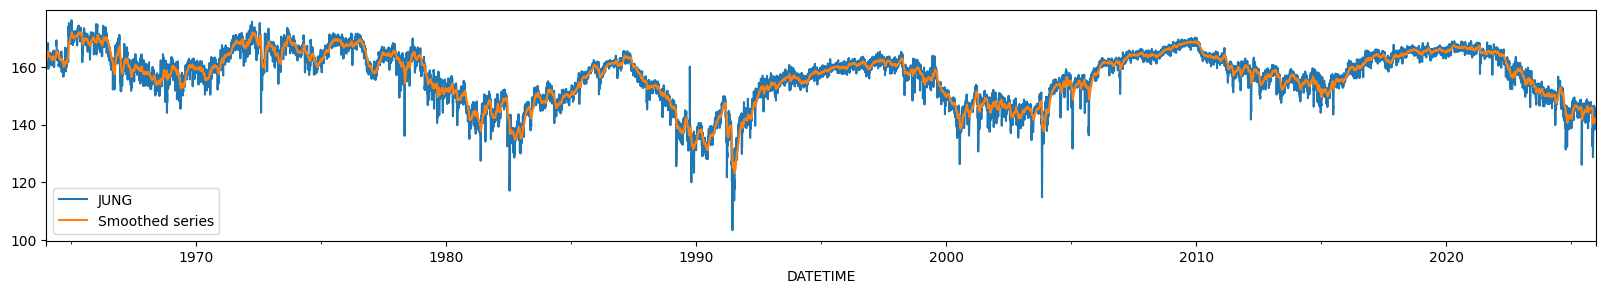

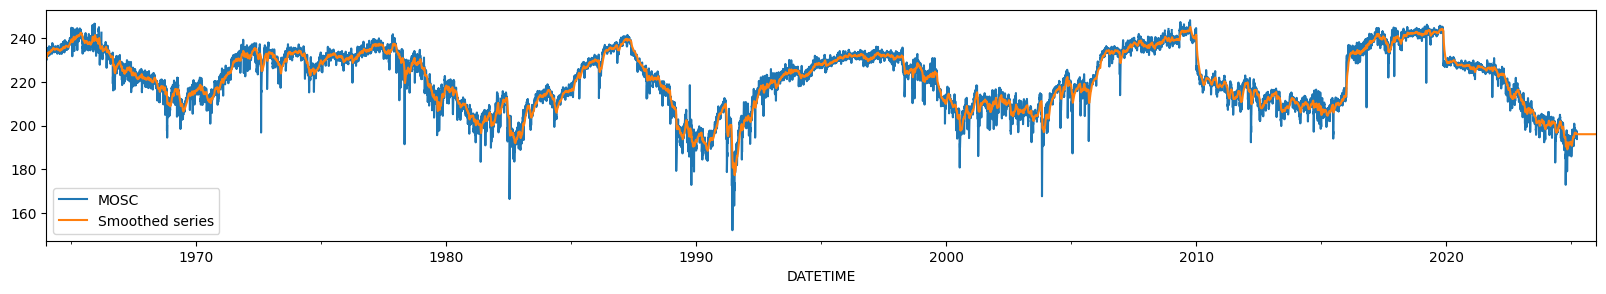

In [4]:
for i in counts_nmdb.columns:
    counts_nmdb[i].plot(figsize=(20,3))
    counts_nmdb[i].ewm(alpha=0.05).mean().plot(figsize=(20,3),label="Smoothed series")
    plt.legend()
    plt.show()

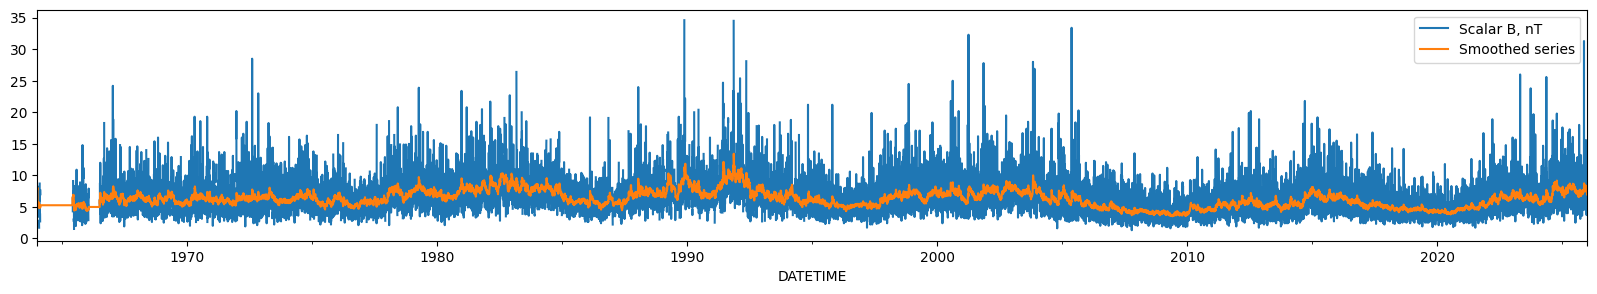

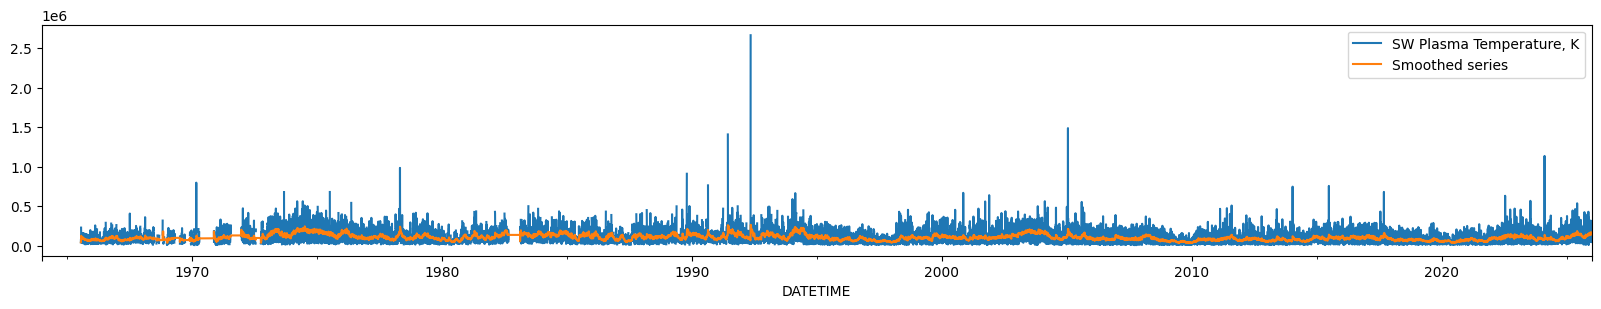

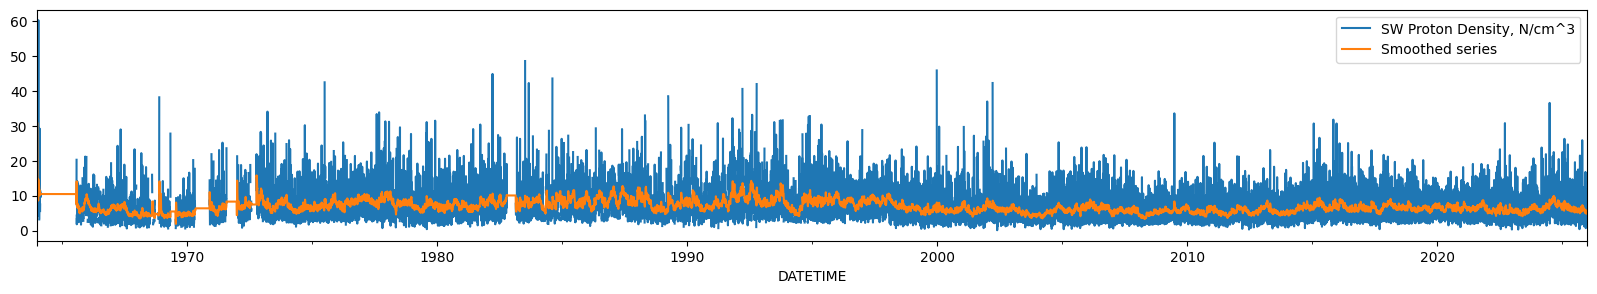

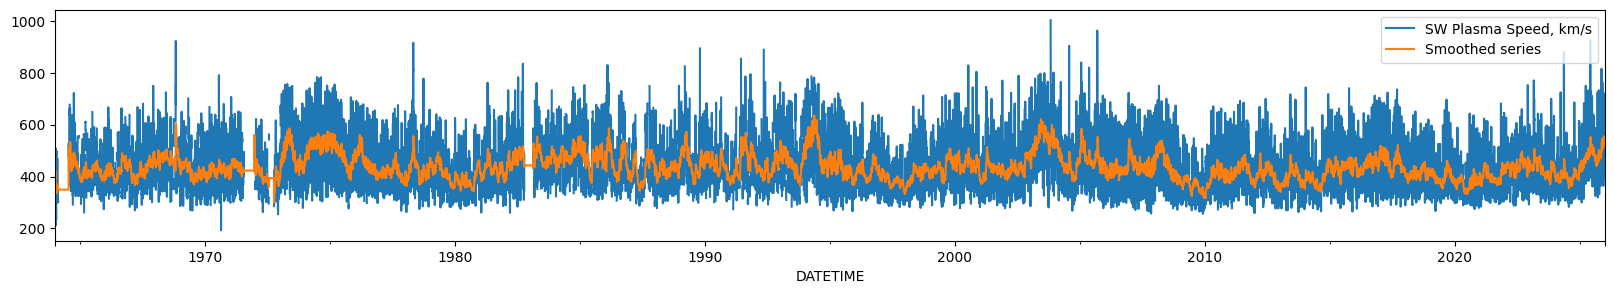

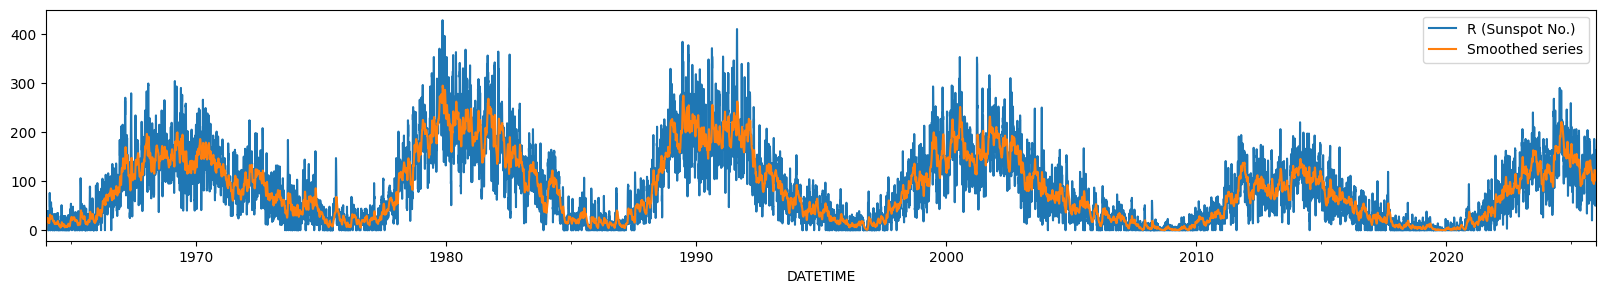

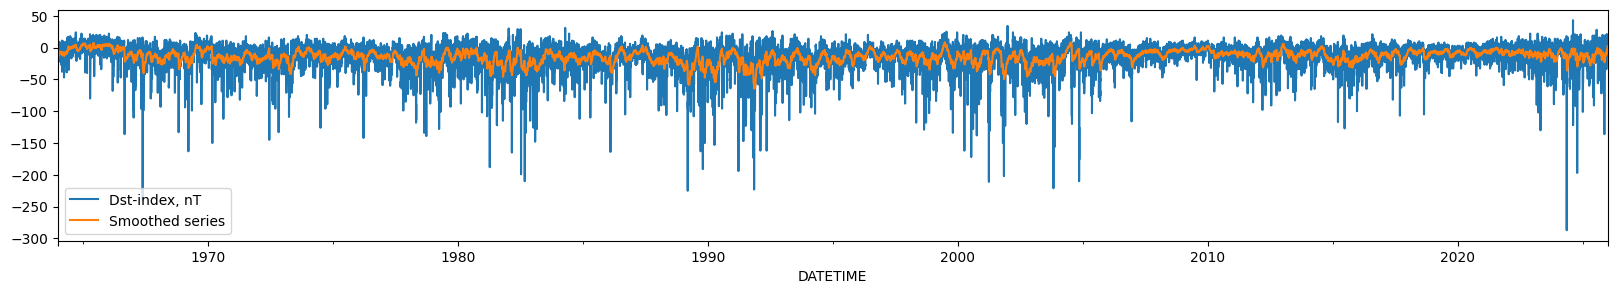

In [5]:
for i in counts_omni.columns:
    counts_omni[i].plot(figsize=(20,3))
    counts_omni[i].ewm(alpha=0.05).mean().plot(figsize=(20,3),label="Smoothed series")
    plt.legend()
    plt.show()

In [14]:
data=pd.merge(counts_nmdb,counts_omni,right_index=True,left_index=True)
data["Cycle"]=np.zeros(len(data))
# Define conditions and choices
conditions = [
    (data.index>="1964")&(data.index<="1976"),
    (data.index>="1976")&(data.index<="1986"),
    (data.index>="1986")&(data.index<="1996"),
    (data.index>="1996")&(data.index<="2008"),
    (data.index>="2008")&(data.index<="2019"),
    (data.index>="2019")]
choices = np.arange(20,26,1)
data["Cycle"]=np.select(conditions, choices, default='F')
data["Cycle"]=data["Cycle"].astype(float)
data

,JUNG,MOSC,"Scalar B, nT","SW Plasma Temperature, K","SW Proton Density, N/cm^3","SW Plasma Speed, km/s",R (Sunspot No.),"Dst-index, nT",Cycle
DATETIME,,,,,,,,,
1964-01-01,163.824,232.529,7.8,NaN,30.7,328.0,0.0,11.0,20.0
1964-01-02,162.334,230.618,8.3,NaN,10.9,505.0,21.0,-41.0,20.0
1964-01-03,160.586,230.268,4.5,NaN,4.3,499.0,12.0,-32.0,20.0
1964-01-04,NaN,229.929,4.6,NaN,4.2,492.0,11.0,-25.0,20.0
1964-01-05,163.766,231.529,3.5,NaN,4.6,375.0,19.0,-19.0,20.0
...,...,...,...,...,...,...,...,...,...
2025-12-27,143.895,NaN,5.0,89571.0,3.0,491.0,150.0,14.0,25.0
2025-12-28,145.154,NaN,5.8,80346.0,4.4,461.0,162.0,13.0,25.0
2025-12-29,145.643,NaN,6.3,46289.0,6.4,415.0,145.0,13.0,25.0


In [15]:
import networkx as nx

In [16]:
G20_jung=nx.visibility_graph(data[data["Cycle"]==20]["JUNG"])

In [17]:
print(G20_jung)

Graph with 4384 nodes and 204307 edges


In [19]:
data.to_csv("All_Data.csv",index=True)